In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv(r"D:\Infosys-Project\AI-PriceOptima\data\clean_dynamic_pricing_dataset.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Standardize naming
df.rename(columns={'units_sold': 'demand'}, inplace=True)

# Create additional features (IMPORTANT)
df['revenue'] = df['price'] * df['demand']
df['profit_margin'] = (df['price'] - df['cost']) / df['price']

df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['is_weekend'] = df['date'].dt.weekday >= 5

df.head()
print(df.shape)
print(df.info())
print(df.describe())

(73100, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                73100 non-null  datetime64[ns]
 1   store_id            73100 non-null  object        
 2   product_id          73100 non-null  object        
 3   category            73100 non-null  object        
 4   region              73100 non-null  object        
 5   inventory_level     73100 non-null  int64         
 6   demand              73100 non-null  int64         
 7   units_ordered       73100 non-null  int64         
 8   demand_forecast     73100 non-null  float64       
 9   price               73100 non-null  float64       
 10  discount            73100 non-null  int64         
 11  weather_condition   73100 non-null  object        
 12  holiday/promotion   73100 non-null  int64         
 13  competitor_pricing  73100 non-null

In [18]:
print(df.shape)
print(df.info())
print(df.describe())

(73100, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                73100 non-null  datetime64[ns]
 1   store_id            73100 non-null  object        
 2   product_id          73100 non-null  object        
 3   category            73100 non-null  object        
 4   region              73100 non-null  object        
 5   inventory_level     73100 non-null  int64         
 6   demand              73100 non-null  int64         
 7   units_ordered       73100 non-null  int64         
 8   demand_forecast     73100 non-null  float64       
 9   price               73100 non-null  float64       
 10  discount            73100 non-null  int64         
 11  weather_condition   73100 non-null  object        
 12  holiday/promotion   73100 non-null  int64         
 13  competitor_pricing  73100 non-null

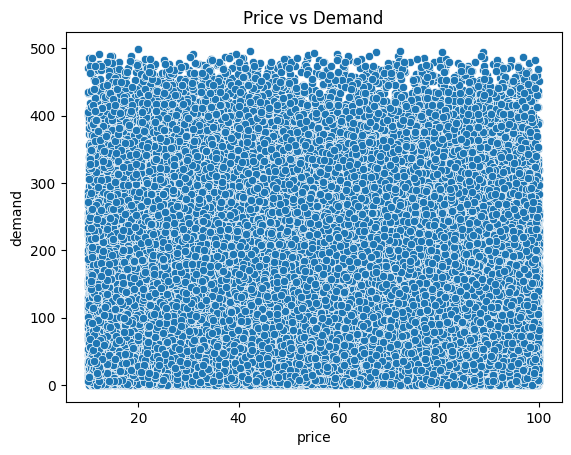

In [19]:
sns.scatterplot(x="price", y="demand", data=df)
plt.title("Price vs Demand")
plt.show()

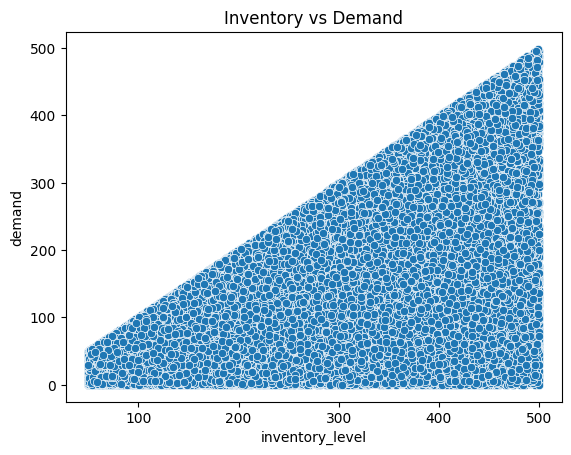

In [20]:
sns.scatterplot(x="inventory_level", y="demand", data=df)
plt.title("Inventory vs Demand")
plt.show()

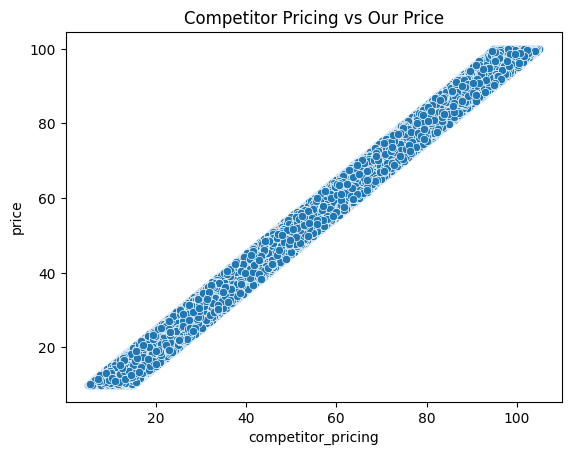

In [21]:
sns.scatterplot(x="competitor_pricing", y="price", data=df)
plt.title("Competitor Pricing vs Our Price")
plt.show()

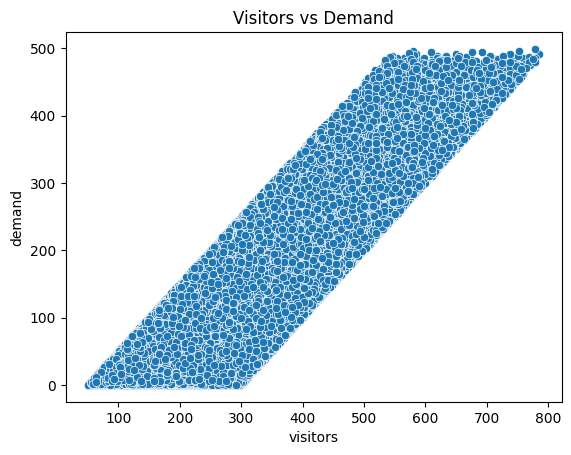

In [22]:
sns.scatterplot(x="visitors", y="demand", data=df)
plt.title("Visitors vs Demand")
plt.show()

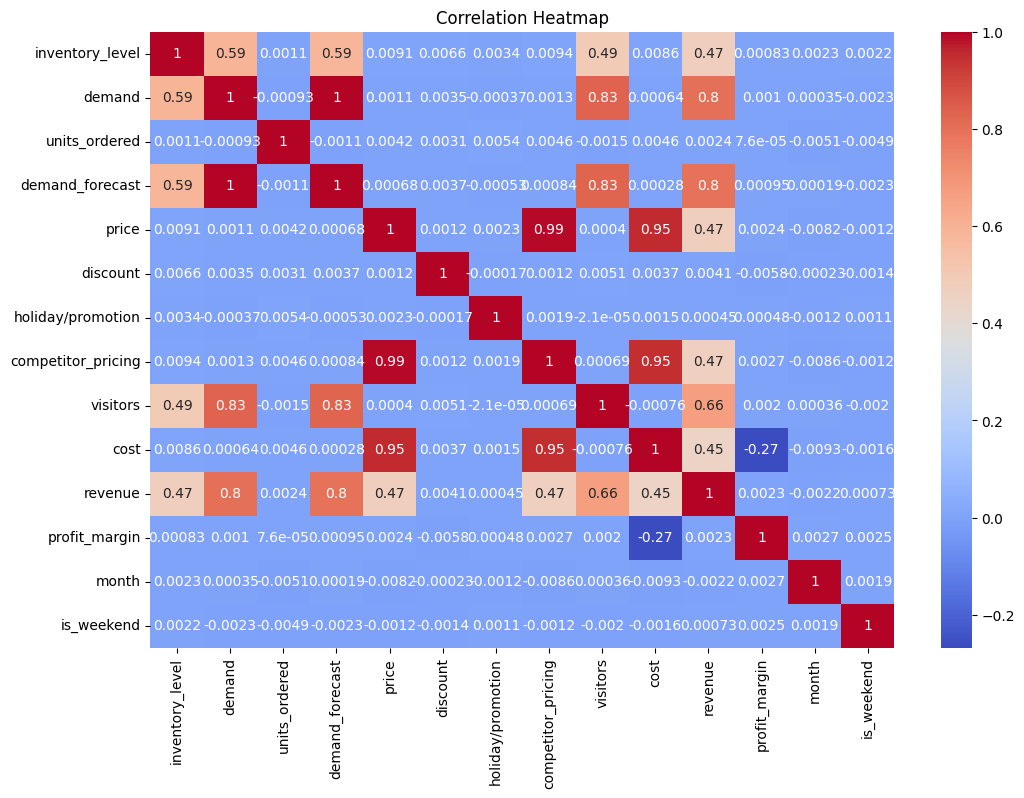

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

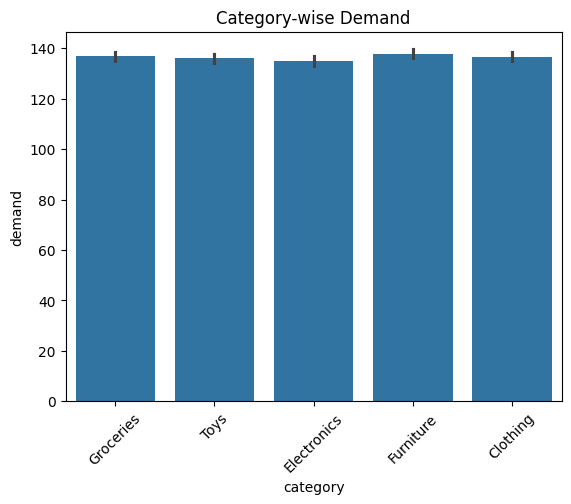

In [24]:
sns.barplot(x="category", y="demand", data=df)
plt.xticks(rotation=45)
plt.title("Category-wise Demand")
plt.show()

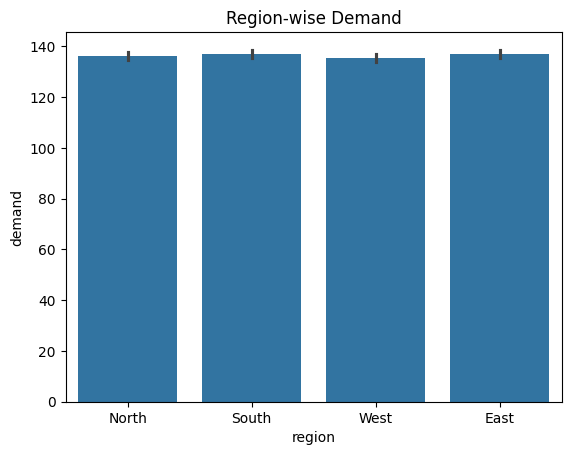

In [25]:
sns.barplot(x="region", y="demand", data=df)
plt.title("Region-wise Demand")
plt.show()

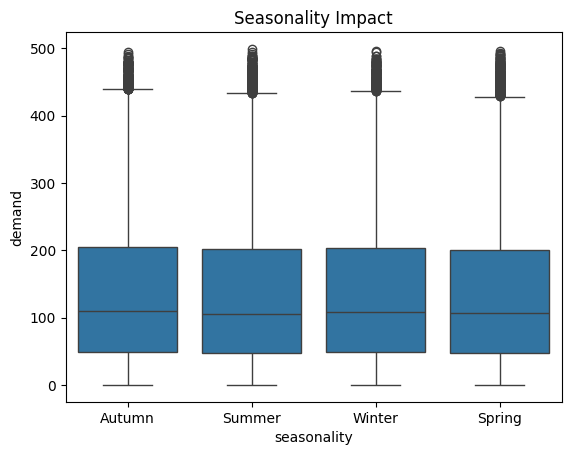

In [26]:
sns.boxplot(x="seasonality", y="demand", data=df)
plt.title("Seasonality Impact")
plt.show()

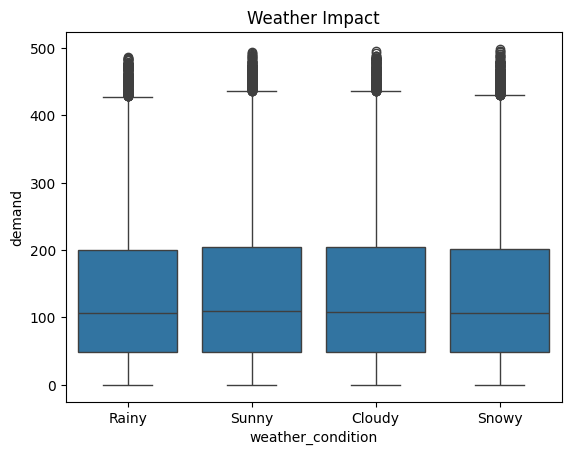

In [27]:
sns.boxplot(x="weather_condition", y="demand", data=df)
plt.title("Weather Impact")
plt.show()

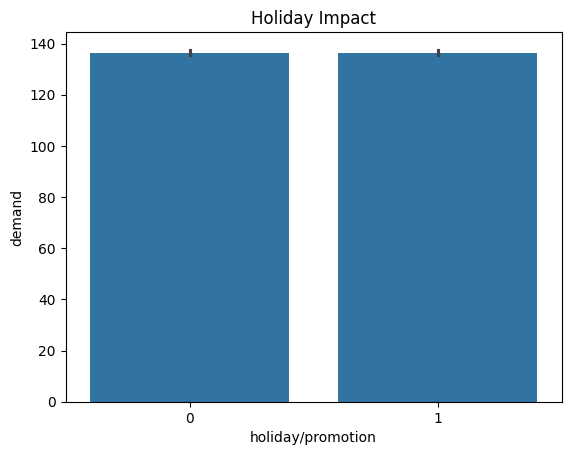

In [28]:
sns.barplot(x="holiday/promotion", y="demand", data=df)
plt.title("Holiday Impact")
plt.show()

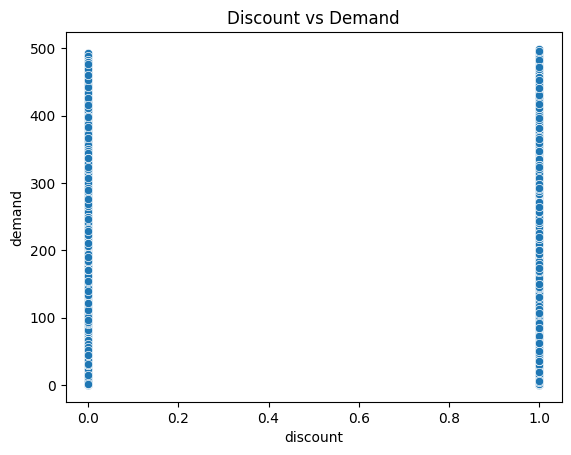

In [29]:
sns.scatterplot(x="discount", y="demand", data=df)
plt.title("Discount vs Demand")
plt.show()

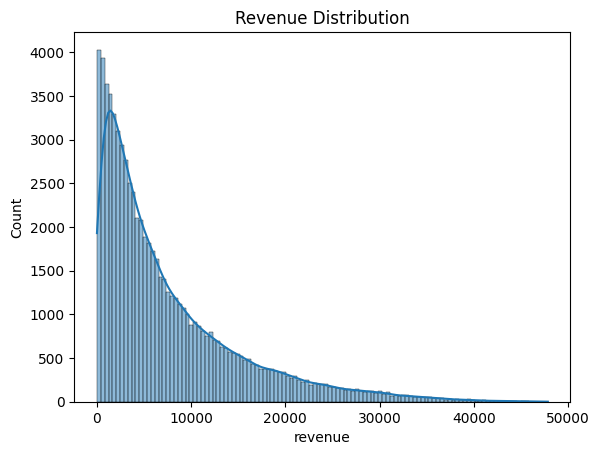

In [30]:
sns.histplot(df["revenue"], kde=True)
plt.title("Revenue Distribution")
plt.show()

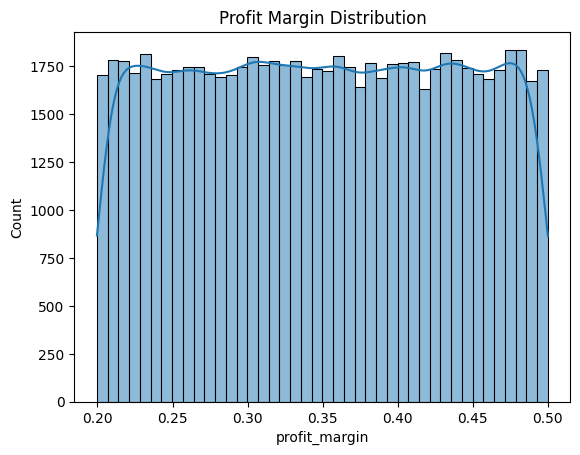

In [31]:
sns.histplot(df["profit_margin"], kde=True)
plt.title("Profit Margin Distribution")
plt.show()

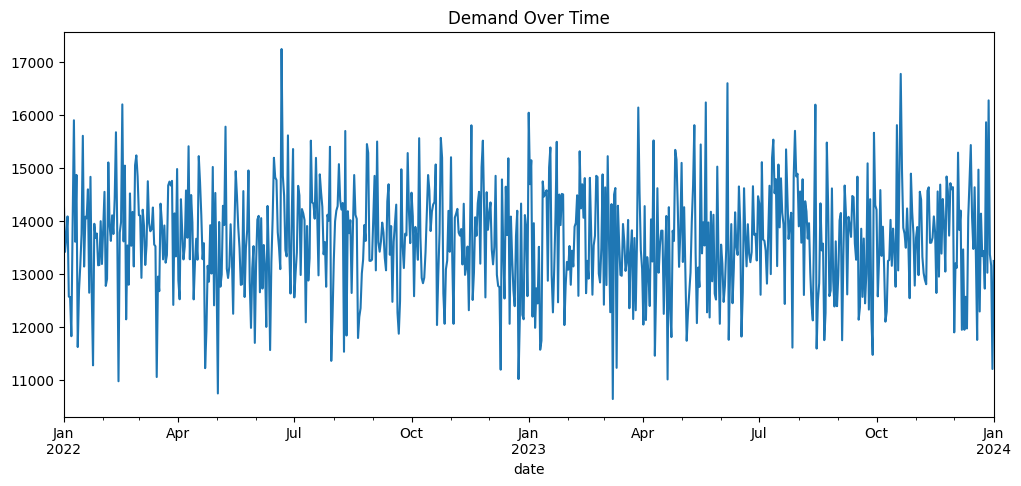

In [32]:
df.groupby("date")["demand"].sum().plot(figsize=(12,5))
plt.title("Demand Over Time")
plt.show()

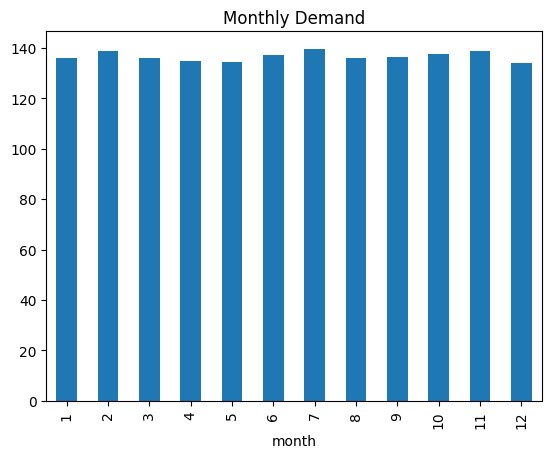

In [33]:
df.groupby("month")["demand"].mean().plot(kind="bar")
plt.title("Monthly Demand")
plt.show()

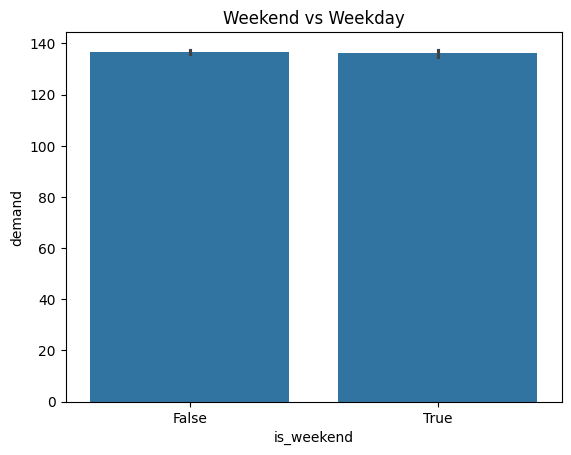

In [34]:
sns.barplot(x="is_weekend", y="demand", data=df)
plt.title("Weekend vs Weekday")
plt.show()

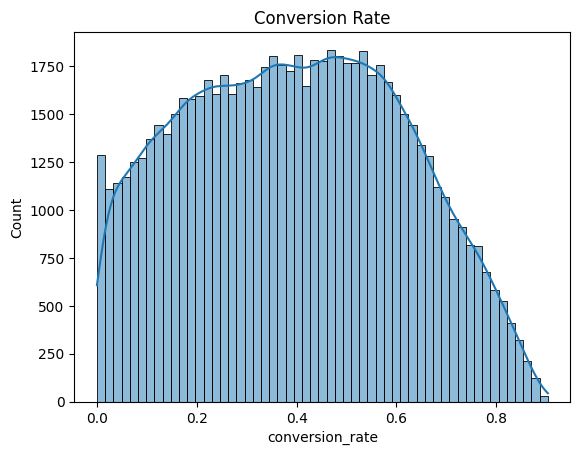

In [35]:
df['conversion_rate'] = df['demand'] / df['visitors']

sns.histplot(df["conversion_rate"], kde=True)
plt.title("Conversion Rate")
plt.show()

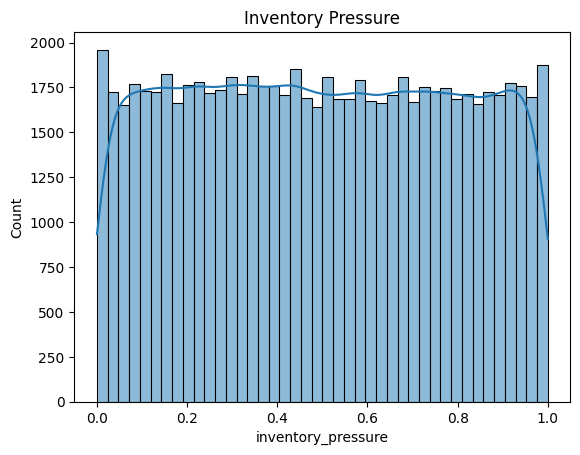

In [36]:
df['inventory_pressure'] = df['demand'] / df['inventory_level']

sns.histplot(df["inventory_pressure"], kde=True)
plt.title("Inventory Pressure")
plt.show()

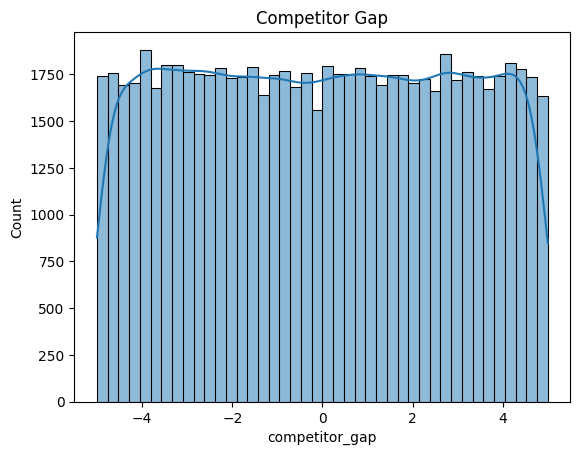

In [37]:
df['competitor_gap'] = df['price'] - df['competitor_pricing']

sns.histplot(df["competitor_gap"], kde=True)
plt.title("Competitor Gap")
plt.show()

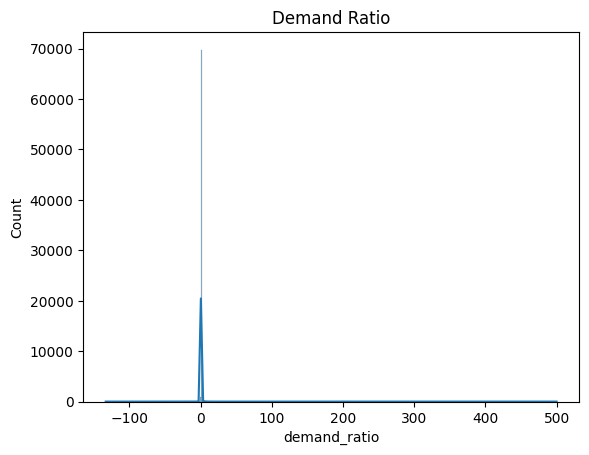

In [38]:
df['demand_ratio'] = df['demand'] / df['demand_forecast']

sns.histplot(df["demand_ratio"], kde=True)
plt.title("Demand Ratio")
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_17748\2694563380.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(price_bins)['revenue'].mean()


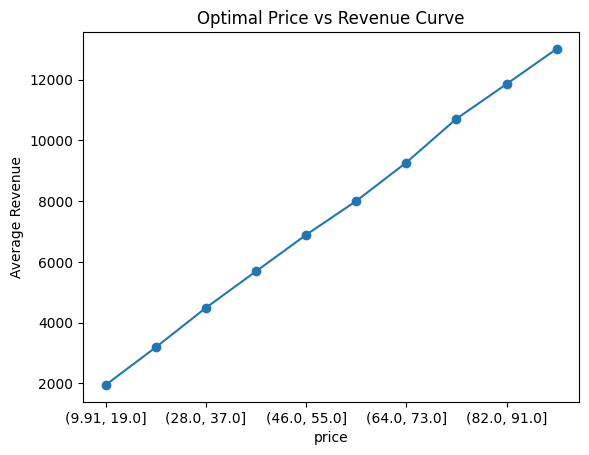

In [39]:
price_bins = pd.cut(df['price'], bins=10)

grouped = df.groupby(price_bins)['revenue'].mean()

grouped.plot(kind='line', marker='o')
plt.title("Optimal Price vs Revenue Curve")
plt.ylabel("Average Revenue")
plt.show()

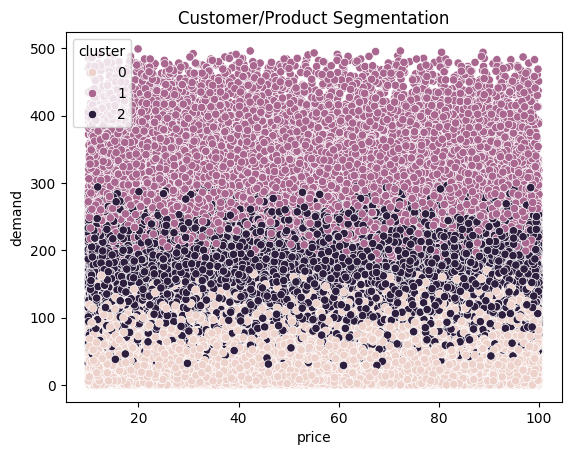

In [40]:
from sklearn.cluster import KMeans

features = df[['price','demand','discount','visitors']].dropna()

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(features)

sns.scatterplot(x=df['price'], y=df['demand'], hue=df['cluster'])
plt.title("Customer/Product Segmentation")
plt.show()

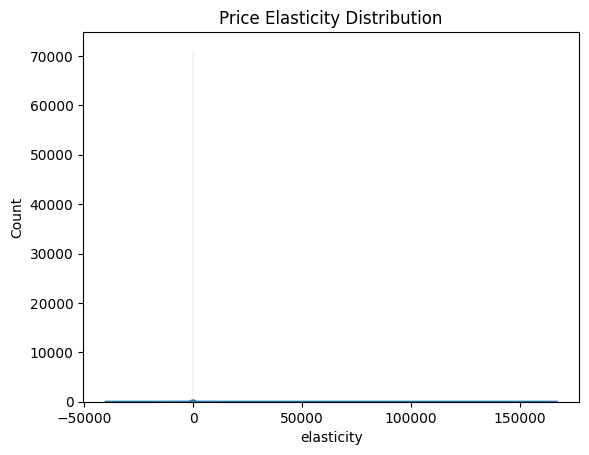

In [41]:
df['price_change'] = df['price'].pct_change()
df['demand_change'] = df['demand'].pct_change()

df['elasticity'] = df['demand_change'] / df['price_change']

sns.histplot(df['elasticity'], kde=True)
plt.title("Price Elasticity Distribution")
plt.show()